# Global Well-Being:
## Exploring the Relationship Between Mental Health, Economic Factors, and Happiness

### Author
Rebecca Rader 

### Project Overview

This project investigates how economic conditions, mental health resources, and social factors relate to national happiness and mental health outcomes across countries. Using data from two global datasets, the analysis explores whether factors such as GDP, access to mental health care, and social media usage are associated with differences in happiness and mental health across nations.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SQLite
import sqlite3

# Display graphs inside notebook
%matplotlib inline

# 3. Data Loading

In [2]:
df = pd.read_csv("../data/cleaned/mental_health_combined.csv")

# 5. Data Cleaning

In [7]:
df.head()

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,...,data_year,data_source,Overall rank,happiness_score,gdp_per_capita_usd_y,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,150.0,3.410,0.191,0.560,0.495,0.443,0.218,0.089
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,123.0,4.466,0.204,0.986,0.390,0.494,0.197,0.138
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,134.0,4.286,0.336,1.033,0.532,0.344,0.209,0.100
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,146.0,3.663,0.366,1.114,0.433,0.361,0.151,0.089
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,153.0,3.231,0.476,0.885,0.499,0.417,0.276,0.147


In [8]:
df.tail()

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,...,data_year,data_source,Overall rank,happiness_score,gdp_per_capita_usd_y,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
87,Sweden,SWE,Europe,High,4.6,4.8,13.9,26.8,10.2,165.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,7.0,7.343,1.387,1.487,1.009,0.574,0.267,0.373
88,Denmark,DNK,Europe,High,4.7,4.9,11.3,19.4,8.9,178.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,2.0,7.600,1.383,1.573,0.996,0.592,0.252,0.410
89,Singapore,SGP,W. Pacific,High,3.5,4.8,9.2,8.6,6.4,82.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,34.0,6.262,1.572,1.463,1.141,0.556,0.271,0.453
90,Switzerland,CHE,Europe,High,4.4,4.7,12.2,54.9,8.2,320.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,6.0,7.480,1.452,1.526,1.052,0.572,0.263,0.343
91,Norway,NOR,Europe,High,4.5,4.6,12.6,31.0,9.8,210.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,3.0,7.554,1.488,1.582,1.028,0.603,0.271,0.341


In [9]:
df.shape

(92, 37)

In [10]:
df.columns

Index(['country', 'iso3', 'region', 'income_group', 'depression_pct',
       'anxiety_pct', 'suicide_rate_per_100k', 'psychiatrists_per100k',
       'mh_budget_pct_of_health_spending', 'mh_spend_per_capita_usd',
       'treatment_gap_pct', 'social_media_hours_daily',
       'internet_penetration_pct', 'gdp_per_capita_usd_x',
       'population_millions', 'covid_mh_increase_pct', 'youth_mh_crisis_score',
       'has_mh_policy', 'has_mh_law', 'mental_health_crisis_index',
       'total_affected_millions', 'psychiatrists_per_million',
       'mh_investment_gap', 'social_media_mental_health_risk',
       'depression_anxiety_comorbidity_est_pct', 'mh_system_score',
       'income_group_code', 'data_year', 'data_source', 'Overall rank',
       'happiness_score', 'gdp_per_capita_usd_y', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per_100k                   92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_of_health_spending        92 non-null     float64
 9   mh_spend_per_capita_usd                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     float64
 11  social

In [12]:
df["has_mh_policy"] = df["has_mh_policy"].astype(bool)

In [13]:
df["has_mh_law"] = df["has_mh_law"].astype(bool)

In [14]:
(df["gdp_per_capita_usd_x"] == df["gdp_per_capita_usd_y"]).all()

np.False_

In [15]:
df[["gdp_per_capita_usd_x", "gdp_per_capita_usd_y"]].describe()

,gdp_per_capita_usd_x,gdp_per_capita_usd_y
count,92.000000,85.000000
mean,22231.608696,1.028612
std,25685.337791,0.330628
min,600.000000,0.191000
25%,3975.000000,0.820000
50%,10150.000000,1.050000
75%,33975.000000,1.301000
max,106900.000000,1.572000


In [16]:
df[[
    "country",
    "gdp_per_capita_usd_x",
    "gdp_per_capita_usd_y"
]].head(10)

,country,gdp_per_capita_usd_x,gdp_per_capita_usd_y
0,Malawi,700,0.191
1,Mozambique,600,0.204
2,Ethiopia,1200,0.336
3,Zimbabwe,1000,0.366
4,Tanzania,1200,0.476
5,Uganda,900,0.332
6,Lesotho,1200,0.489
7,Eswatini,4200,NaN
8,Ukraine,4108,0.820
9,Nigeria,2200,0.696


In [17]:
df = df.rename(columns={
    "gdp_per_capita_usd_x": "gdp_per_capita_usd",
    "gdp_per_capita_usd_y": "happiness_gdp_factor"
})

In [18]:
df = df.rename(columns={
    "Overall rank": "overall_rank",
    "Social support": "social_support",
    "Healthy life expectancy": "healthy_life_expectancy",
    "Freedom to make life choices": "freedom_to_make_life_choices",
    "Perceptions of corruption": "perceptions_of_corruption"
})

In [19]:
df.describe()

,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,...,income_group_code,data_year,overall_rank,happiness_score,happiness_gdp_factor,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.0,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,4.402174,5.632609,11.559783,7.182283,3.758696,38.951087,58.934783,2.209783,73.750000,22231.608696,...,2.923913,2025.0,67.917647,5.690247,1.028612,1.287647,0.808824,0.423659,0.182835,0.125165
std,0.754471,1.201657,9.825511,9.485814,2.960366,63.418593,27.884694,0.786711,24.262133,25685.337791,...,1.008030,0.0,45.130027,1.106188,0.330628,0.238595,0.203602,0.125802,0.106557,0.108770
min,2.900000,3.800000,3.200000,0.020000,0.600000,0.100000,17.000000,0.100000,8.000000,600.000000,...,1.000000,2025.0,1.000000,3.231000,0.191000,0.560000,0.168000,0.067000,0.000000,0.005000
25%,3.800000,4.800000,7.575000,0.500000,1.200000,0.725000,26.000000,1.600000,68.750000,3975.000000,...,2.000000,2025.0,26.000000,4.722000,0.820000,1.147000,0.706000,0.351000,0.099000,0.050000
50%,4.400000,5.200000,9.800000,3.150000,2.850000,8.000000,64.500000,2.100000,82.500000,10150.000000,...,3.000000,2025.0,65.000000,5.697000,1.050000,1.360000,0.828000,0.443000,0.160000,0.089000
75%,4.900000,6.100000,12.825000,12.450000,5.650000,49.750000,84.500000,2.800000,92.250000,33975.000000,...,4.000000,2025.0,106.000000,6.444000,1.301000,1.475000,0.987000,0.516000,0.260000,0.161000
max,6.300000,9.300000,87.500000,54.900000,11.300000,320.000000,97.000000,4.800000,99.000000,106900.000000,...,4.000000,2025.0,153.000000,7.769000,1.572000,1.587000,1.141000,0.631000,0.566000,0.453000


In [20]:
df.describe(include="object")

C:\Users\Otters4Life\AppData\Local\Temp\ipykernel_41424\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,country,iso3,region,income_group,social_media_mental_health_risk,data_source
count,92,92,92,92,92,92
unique,92,92,6,4,4,1
top,Malawi,MWI,Europe,High,Moderate (1.5-2.5h),WHO Mental Health Atlas 2024 | GBD Study 2023 ...
freq,1,1,32,35,44,92


In [21]:
df.sample(5)

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per_100k,psychiatrists_per100k,mh_budget_pct_of_health_spending,mh_spend_per_capita_usd,...,data_year,data_source,overall_rank,happiness_score,happiness_gdp_factor,social_support,healthy_life_expectancy,freedom_to_make_life_choices,Generosity,perceptions_of_corruption
18,Venezuela,VEN,Americas,Upper-Middle,4.6,6.0,8.8,0.7,0.9,0.4,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,108.0,4.707,0.960,1.427,0.805,0.154,0.064,0.047
83,Spain,ESP,Europe,High,4.5,5.0,8.5,10.8,5.2,42.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,30.0,6.354,1.286,1.484,1.062,0.362,0.153,0.079
54,China,CHN,W. Pacific,Upper-Middle,4.0,4.6,8.0,2.2,2.2,4.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,93.0,5.191,1.029,1.125,0.893,0.521,0.058,0.100
56,Hungary,HUN,Europe,High,5.0,5.4,19.1,6.2,3.8,22.0,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,62.0,5.758,1.201,1.410,0.828,0.199,0.081,0.020
28,Tunisia,TUN,Africa,Lower-Middle,4.3,7.1,3.8,0.8,1.5,1.2,...,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,124.0,4.461,0.921,1.000,0.815,0.167,0.059,0.055


## Exploratory Data Analysis

Before conducting any analysis, the dataset was examined for missing values, duplicate records, incorrect data types, and potential outliers. This step ensures the data is accurate, consistent, and suitable for answering the project's research questions.

In [22]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

healthy_life_expectancy         7
social_support                  7
happiness_gdp_factor            7
happiness_score                 7
overall_rank                    7
Generosity                      7
freedom_to_make_life_choices    7
perceptions_of_corruption       7
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per_100k                   92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_of_health_spending        92 non-null     float64
 9   mh_spend_per_capita_usd                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     float64
 11  social

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
depression_pct,92.0,4.402174,0.754471,2.900,3.8000,4.4000,4.9000,6.300
anxiety_pct,92.0,5.632609,1.201657,3.800,4.8000,5.2000,6.1000,9.300
suicide_rate_per_100k,92.0,11.559783,9.825511,3.200,7.5750,9.8000,12.8250,87.500
psychiatrists_per100k,92.0,7.182283,9.485814,0.020,0.5000,3.1500,12.4500,54.900
mh_budget_pct_of_health_spending,92.0,3.758696,2.960366,0.600,1.2000,2.8500,5.6500,11.300
mh_spend_per_capita_usd,92.0,38.951087,63.418593,0.100,0.7250,8.0000,49.7500,320.000
treatment_gap_pct,92.0,58.934783,27.884694,17.000,26.0000,64.5000,84.5000,97.000
social_media_hours_daily,92.0,2.209783,0.786711,0.100,1.6000,2.1000,2.8000,4.800
internet_penetration_pct,92.0,73.750000,24.262133,8.000,68.7500,82.5000,92.2500,99.000
gdp_per_capita_usd,92.0,22231.608696,25685.337791,600.000,3975.0000,10150.0000,33975.0000,106900.000


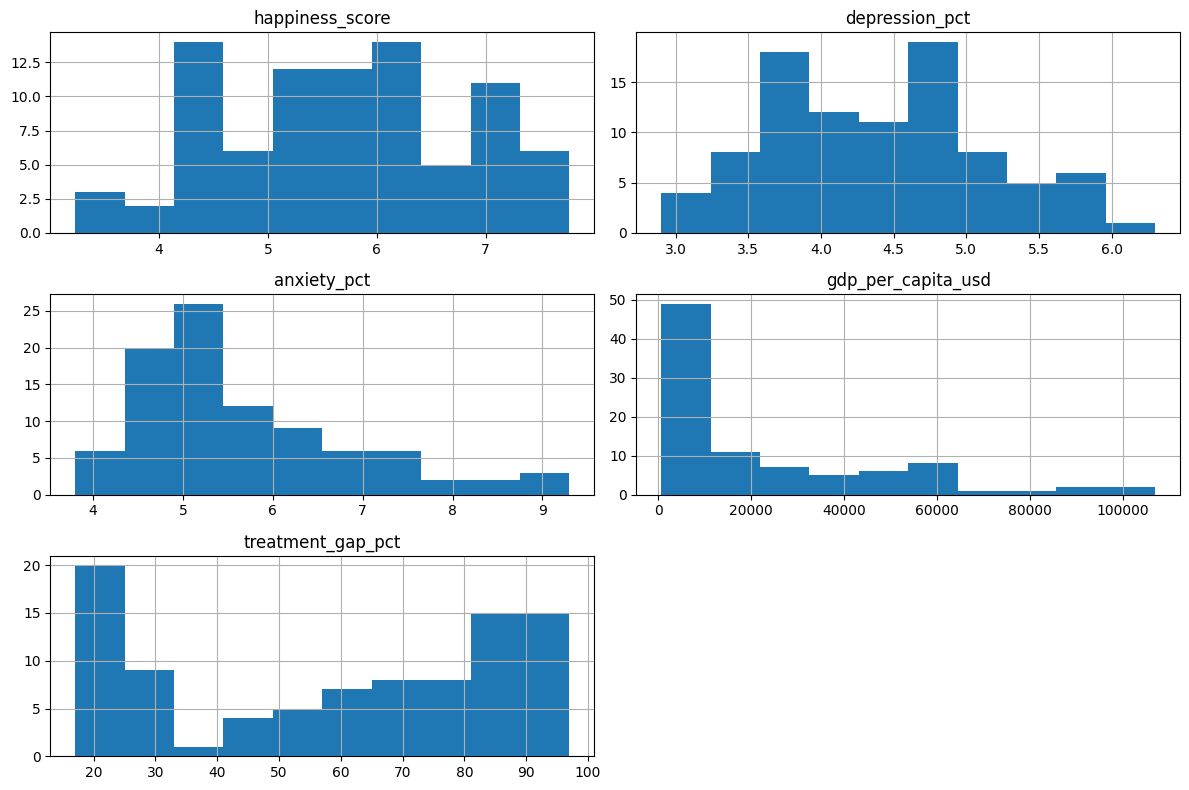

In [26]:
columns = [
    "happiness_score",
    "depression_pct",
    "anxiety_pct",
    "gdp_per_capita_usd",
    "treatment_gap_pct"
]

df[columns].hist(figsize=(12,8))
plt.tight_layout()

Text(0.5, 1.0, 'GDP per Capita Distribution')

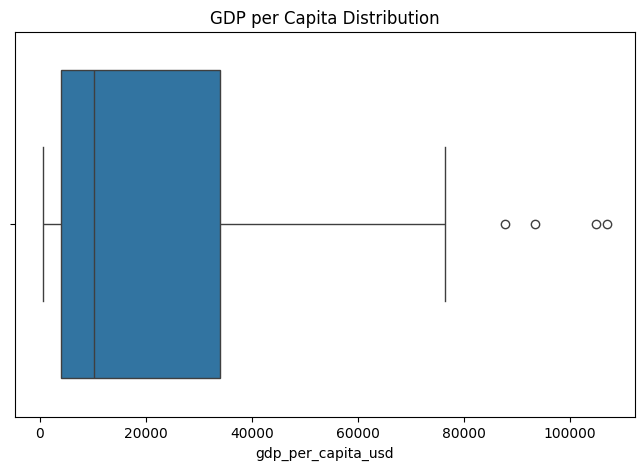

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["gdp_per_capita_usd"]
)

plt.title("GDP per Capita Distribution")

Text(0.5, 1.0, 'Depression Percentage Distribution')

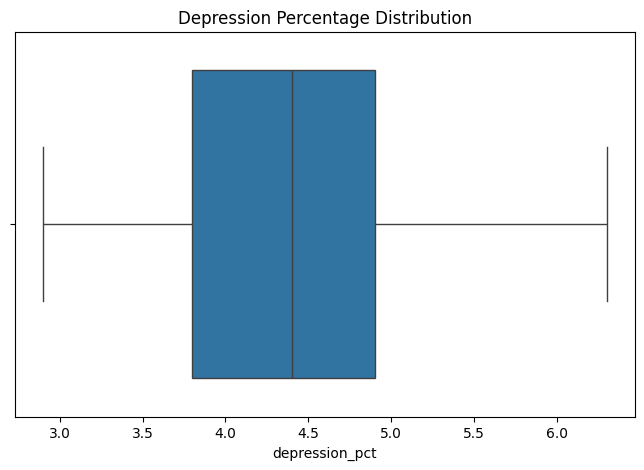

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["depression_pct"]
)

plt.title("Depression Percentage Distribution")

Text(0.5, 1.0, 'Anxiety Percentage Distribution')

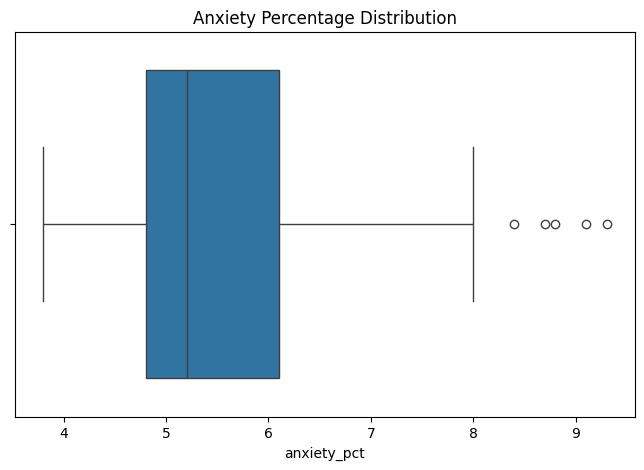

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["anxiety_pct"]
)

plt.title("Anxiety Percentage Distribution")

Text(0.5, 1.0, 'Treatment Gap Percentage Distribution')

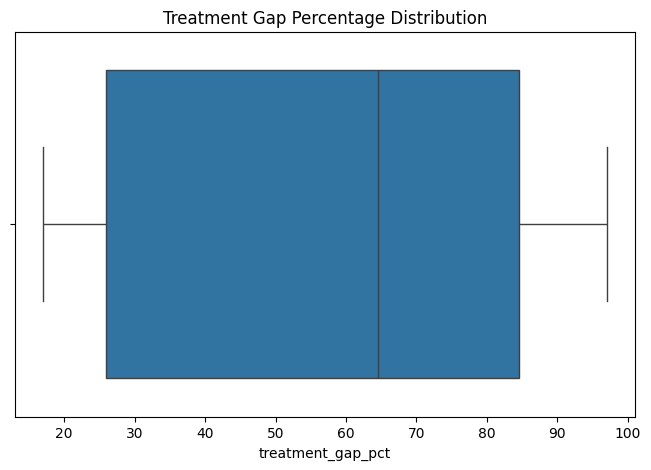

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["treatment_gap_pct"]
)

plt.title("Treatment Gap Percentage Distribution")

In [31]:
numeric_df = df.select_dtypes(include="number")

In [32]:
corr = numeric_df.corr()

Text(0.5, 1.0, 'Correlation Matrix')

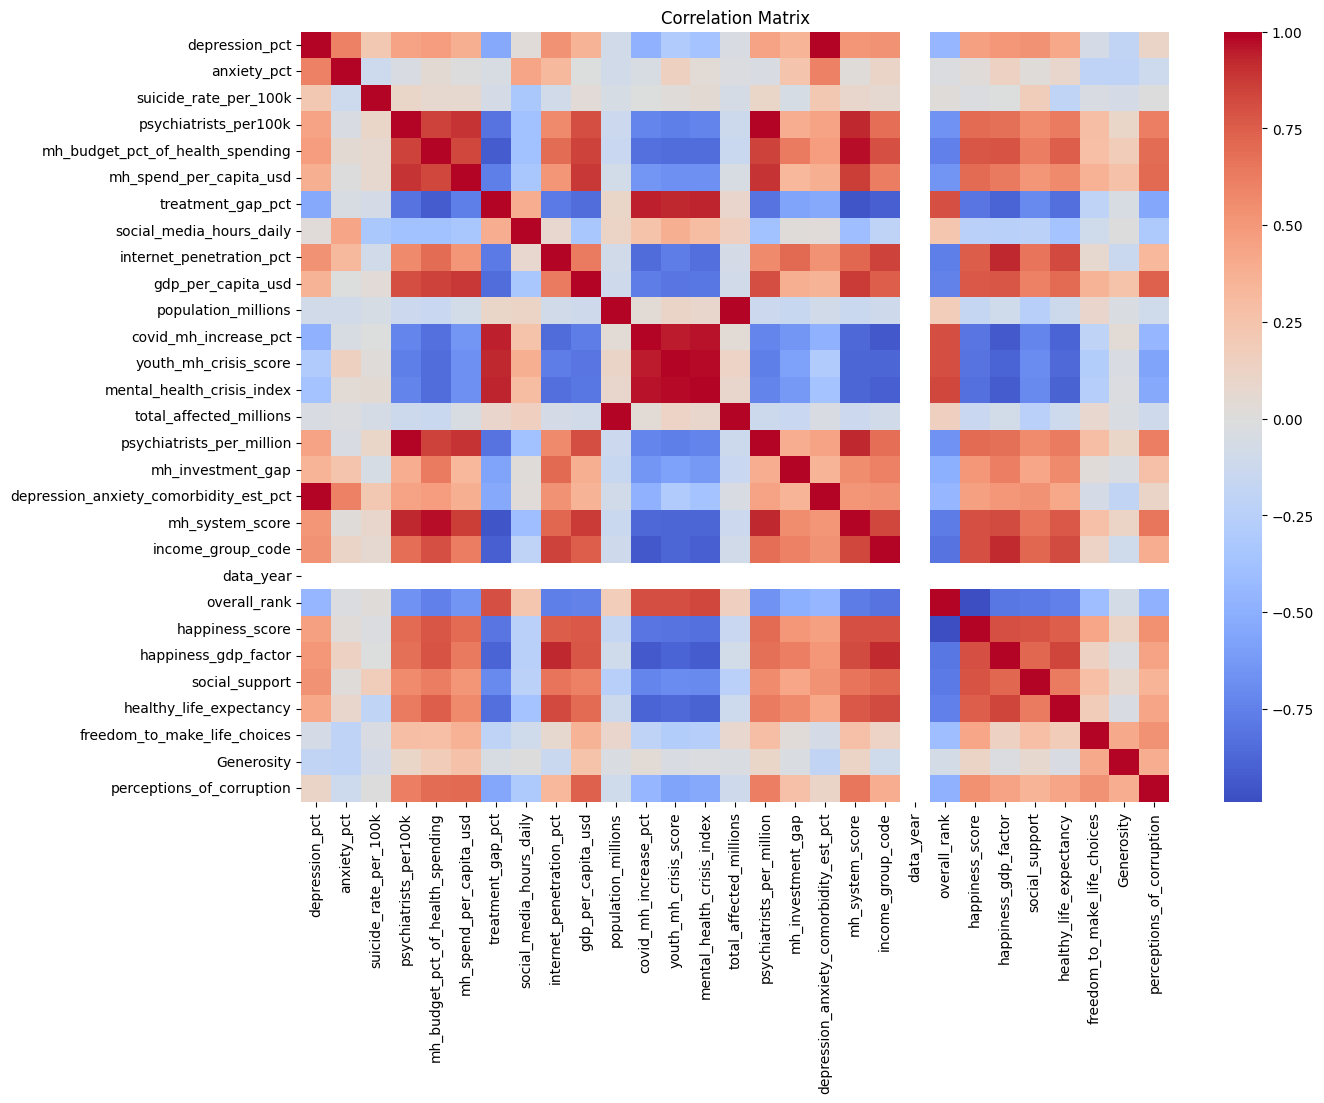

In [33]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

The exploratory analysis showed that the merged dataset is generally clean and suitable for analysis. No duplicate records were found, and data types were appropriate for their respective variables. Seven countries were missing data from the World Happiness Report, resulting in missing values across several happiness-related variables. Initial visualizations revealed variation in GDP per capita, treatment gap percentages, and happiness scores, with some expected outliers among high-income countries. These observations will guide the subsequent data cleaning and analysis steps.

# 5. Research Questions

This section explores the relationships between mental health, economic indicators, healthcare resources, and national happiness. Each research question is investigated using descriptive statistics and visualizations to identify trends and patterns within the dataset.

# Research Question 1

## Is there a relationship between GDP per capita and national happiness?

Economic prosperity is often associated with quality of life, but wealth alone may not determine how happy a population is. This analysis investigates whether countries with higher GDP per capita tend to report higher happiness scores.

In [34]:
df[["country", "gdp_per_capita_usd", "happiness_score"]].head()

,country,gdp_per_capita_usd,happiness_score
0,Malawi,700,3.410
1,Mozambique,600,4.466
2,Ethiopia,1200,4.286
3,Zimbabwe,1000,3.663
4,Tanzania,1200,3.231


In [35]:
df[["gdp_per_capita_usd", "happiness_score"]].isnull().sum()

gdp_per_capita_usd    0
happiness_score       7
dtype: int64

In [36]:
gdp_happiness = df[["gdp_per_capita_usd", "happiness_score"]].dropna()

In [37]:
gdp_happiness.describe()

,gdp_per_capita_usd,happiness_score
count,85.000000,85.000000
mean,23150.682353,5.690247
std,26105.406237,1.106188
min,600.000000,3.231000
25%,4000.000000,4.722000
50%,11200.000000,5.697000
75%,34800.000000,6.444000
max,106900.000000,7.769000


The GDP per capita values vary substantially across countries, indicating a wide range of economic conditions. Happiness scores also show noticeable variation, suggesting meaningful differences in reported well-being between countries.

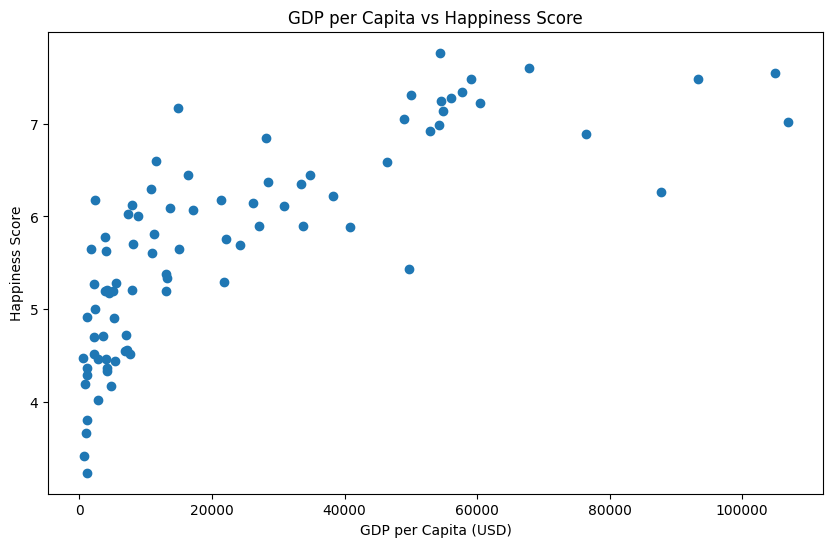

In [38]:
plt.figure(figsize=(10,6))

plt.scatter(
    gdp_happiness["gdp_per_capita_usd"],
    gdp_happiness["happiness_score"]
)

plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Happiness Score")

plt.show()

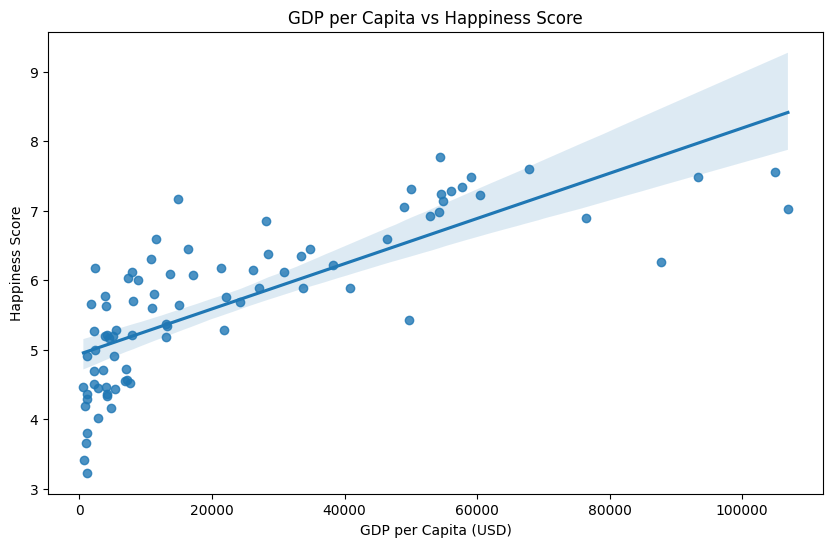

In [39]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=gdp_happiness,
    x="gdp_per_capita_usd",
    y="happiness_score"
)

plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Happiness Score")

plt.show()

In [40]:
correlation = gdp_happiness["gdp_per_capita_usd"].corr(
    gdp_happiness["happiness_score"]
)

print(correlation)

0.7678234008133268


| Correlation     | Interpretation            |
| --------------- | ------------------------- |
| 0.90–1.00       | Very strong positive      |
| 0.70–0.89       | Strong positive           |
| 0.50–0.69       | Moderate positive         |
| 0.30–0.49       | Weak positive             |
| 0.00–0.29       | Little or no relationship |
| Negative values | Inverse relationship      |


In [41]:
df.nlargest(10, "happiness_score")[
    ["country", "gdp_per_capita_usd", "happiness_score"]
]

,country,gdp_per_capita_usd,happiness_score
82,Finland,54400,7.769
88,Denmark,67900,7.600
91,Norway,104900,7.554
86,Netherlands,59100,7.488
90,Switzerland,93400,7.480
87,Sweden,57700,7.343
70,New Zealand,50100,7.307
77,Canada,56100,7.278
84,Austria,54600,7.246
72,Australia,60400,7.228


In [42]:
df.nlargest(10, "gdp_per_capita_usd")[
    ["country", "gdp_per_capita_usd", "happiness_score"]
]

,country,gdp_per_capita_usd,happiness_score
81,Ireland,106900,7.021
91,Norway,104900,7.554
90,Switzerland,93400,7.480
89,Singapore,87800,6.262
59,United States,76400,6.892
88,Denmark,67900,7.600
72,Australia,60400,7.228
86,Netherlands,59100,7.488
87,Sweden,57700,7.343
77,Canada,56100,7.278


The scatter plot demonstrates a positive relationship between GDP per capita and national happiness. Countries with higher GDP per capita generally report higher happiness scores, although the relationship is not perfect.

The calculated correlation coefficient of 0.77 indicates a strong positive relationship between the two variables. This suggests that economic prosperity is associated with greater national happiness, but additional factors such as social support, healthcare, and personal freedoms may also contribute to overall well-being.

Overall, the findings support the idea that wealth contributes to national happiness. However, the presence of countries with similar GDP levels but different happiness scores suggests that economic prosperity alone does not fully explain well-being.

# Research Question 2

## Does greater access to mental health care reduce treatment gaps?

Access to mental health services is an important factor in ensuring people receive the care they need. This section investigates whether countries with greater mental health resources, such as more psychiatrists and higher mental health spending, tend to have smaller treatment gaps.

In [43]:
df[[
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]].describe()

,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
count,92.000000,92.000000,92.000000
mean,7.182283,38.951087,58.934783
std,9.485814,63.418593,27.884694
min,0.020000,0.100000,17.000000
25%,0.500000,0.725000,26.000000
50%,3.150000,8.000000,64.500000
75%,12.450000,49.750000,84.500000
max,54.900000,320.000000,97.000000


In [44]:
df[[
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]].isnull().sum()

psychiatrists_per100k      0
mh_spend_per_capita_usd    0
treatment_gap_pct          0
dtype: int64

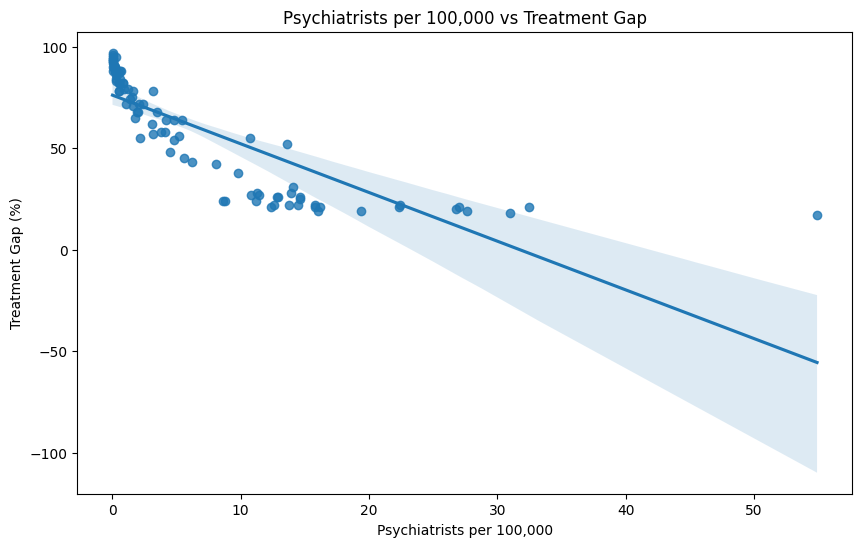

In [45]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="psychiatrists_per100k",
    y="treatment_gap_pct"
)

plt.title("Psychiatrists per 100,000 vs Treatment Gap")
plt.xlabel("Psychiatrists per 100,000")
plt.ylabel("Treatment Gap (%)")

plt.show()

In [46]:
corr_psych = df["psychiatrists_per100k"].corr(
    df["treatment_gap_pct"]
)

print(corr_psych)

-0.8157152024249674


A strong negative correlation was observed between the number of psychiatrists per 100,000 people and the treatment gap percentage. Countries with more psychiatrists generally experienced lower treatment gaps, suggesting that greater availability of mental health professionals may improve access to care.

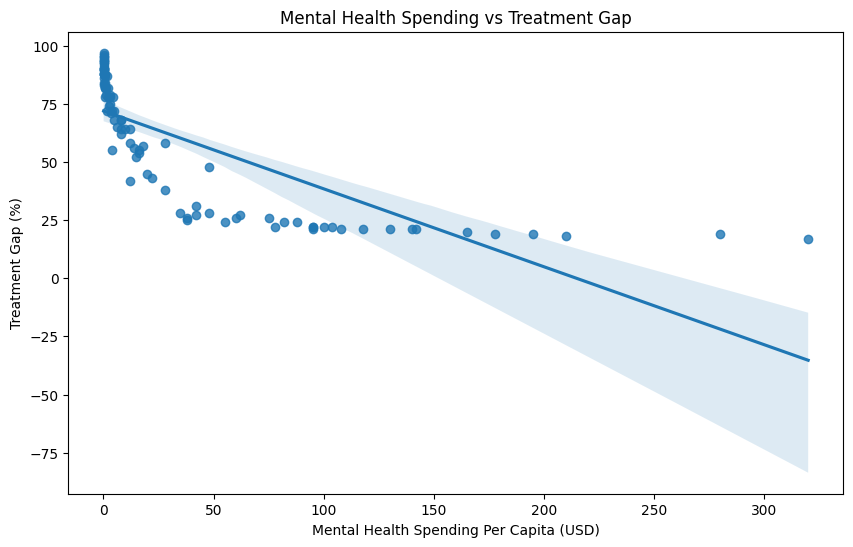

In [47]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="mh_spend_per_capita_usd",
    y="treatment_gap_pct"
)

plt.title("Mental Health Spending vs Treatment Gap")
plt.xlabel("Mental Health Spending Per Capita (USD)")
plt.ylabel("Treatment Gap (%)")

plt.show()

In [48]:
corr_spending = df["mh_spend_per_capita_usd"].corr(
    df["treatment_gap_pct"]
)

print(corr_spending)

-0.7623376961069612


In [49]:
income_gap = (
    df.groupby("income_group")["treatment_gap_pct"]
      .mean()
      .sort_values()
)

income_gap

income_group
High            27.142857
Upper-Middle    66.652174
Lower-Middle    84.038462
Low             94.250000
Name: treatment_gap_pct, dtype: float64

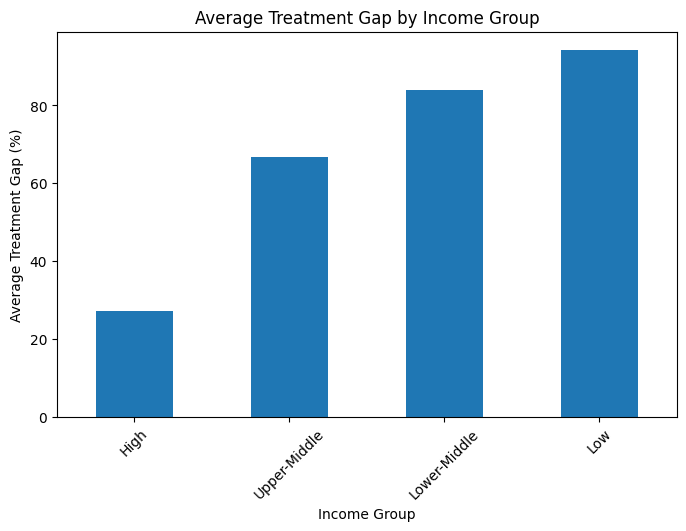

In [50]:
plt.figure(figsize=(8,5))

income_gap.plot(kind="bar")

plt.title("Average Treatment Gap by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Treatment Gap (%)")

plt.xticks(rotation=45)

plt.show()

In [51]:
df.nsmallest(
    10,
    "treatment_gap_pct"
)[[
    "country",
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]]

,country,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
90,Switzerland,54.9,320.0,17.0
91,Norway,31.0,210.0,18.0
59,United States,16.0,280.0,19.0
82,Finland,27.6,195.0,19.0
88,Denmark,19.4,178.0,19.0
87,Sweden,26.8,165.0,20.0
70,New Zealand,12.4,95.0,21.0
75,Belgium,32.5,130.0,21.0
77,Canada,16.2,140.0,21.0
84,Austria,22.3,108.0,21.0


In [52]:
df.nlargest(
    10,
    "treatment_gap_pct"
)[[
    "country",
    "psychiatrists_per100k",
    "mh_spend_per_capita_usd",
    "treatment_gap_pct"
]]

,country,psychiatrists_per100k,mh_spend_per_capita_usd,treatment_gap_pct
0,Malawi,0.02,0.1,97.0
1,Mozambique,0.04,0.1,96.0
2,Ethiopia,0.04,0.1,95.0
10,North Korea,0.30,0.1,95.0
3,Zimbabwe,0.05,0.1,94.0
4,Tanzania,0.04,0.1,94.0
5,Uganda,0.08,0.1,93.0
6,Lesotho,0.05,0.2,93.0
7,Eswatini,0.08,0.2,92.0
11,Ghana,0.10,0.2,91.0


The analysis suggests that countries with greater access to mental health resources generally experience smaller treatment gaps. Both the number of psychiatrists per 100,000 people and mental health spending per capita showed a negative relationship with treatment gap percentage, indicating that greater investment in mental health care may improve access to treatment.

When comparing countries by income group, higher-income countries generally exhibited smaller treatment gaps than lower-income countries. This finding suggests that economic resources may play an important role in expanding access to mental health services.

In [53]:
correlations = pd.DataFrame({
    "Variable": [
        "Psychiatrists per 100k",
        "Mental Health Spending"
    ],
    "Correlation with Treatment Gap": [
        corr_psych,
        corr_spending
    ]
})

correlations

,Variable,Correlation with Treatment Gap
0,Psychiatrists per 100k,-0.815715
1,Mental Health Spending,-0.762338
